<a href="https://colab.research.google.com/github/Abhinav9818/Transformer-from-Scratch-Pytorch-/blob/main/Transformer_Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install datasets sentencepiece spacy -q

!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm
import torch
import spacy

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
dataset = load_dataset("bentrevett/multi30k")

train_data = dataset["train"]
valid_data = dataset["validation"]
test_data = dataset["test"]

print(train_data[0])
spacy_en = spacy.load("en_core_web_sm")
spacy_de = spacy.load("de_core_news_sm")

def tokenize_en(text):
    return [token.text.lower() for token in spacy_en.tokenizer(text)]

def tokenize_de(text):
    return [token.text.lower() for token in spacy_de.tokenizer(text)]



spacy_en = spacy.load("en_core_web_sm")
spacy_de = spacy.load("de_core_news_sm")

def tokenize_en(text):
    return [token.text.lower() for token in spacy_en.tokenizer(text)]

def tokenize_de(text):
    return [token.text.lower() for token in spacy_de.tokenizer(text)]



sentence = train_data[0]["en"]
print(sentence)
print() # leaves a line
tokens = tokenize_en(sentence)
print(tokens)
print()
sentence = train_data[0]["de"]
print(sentence)
print()
tokens = tokenize_de(sentence)
print(tokens)


from collections import Counter
special_tokens = ["<PAD>","<UNK>","<BOS>","<EOS>"]
def build_vocab(dataset,language,tokenizer,min_freq = 2):
  counter = Counter()
  for example in dataset:
    tokens = tokenizer(example[language])
    counter.update(tokens)
  vocab = {}
  for idx,token in enumerate(special_tokens):
    vocab[token] = idx
  idx = len(special_tokens)
  for word,freq  in counter.items():
    if freq >= min_freq:
      vocab[word] = idx
      idx = idx + 1
  return vocab
src_vocab = build_vocab(train_data,"en",tokenize_en)
tgt_vocab = build_vocab(train_data,"de",tokenize_de)
print(len(src_vocab))
print()
print(len(tgt_vocab))

def numericalize(sentence,vocab,tokenizer):
  tokens = tokenizer(sentence)
  ids = [vocab["<BOS>"]]
  for token in tokens:
    ids.append(vocab.get(token,vocab["<UNK>"]))
  ids.append(vocab["<EOS>"])
  return ids
sample = train_data[0]
print(sample["en"])
print()
src_id = numericalize(sample["en"],src_vocab,tokenize_en)
print(src_id)
tgt_id = numericalize(sample["de"],tgt_vocab,tokenize_de)
print(tgt_id)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 112.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 111.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
{'en': 'Two young, White males are outside near many bushes.', 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}
Two young, White males are 

In [12]:
from torch.utils.data import Dataset
class TranslationDataset(Dataset):
  def __init__(self,dataset,src_vocab,tgt_vocab):
    self.dataset = dataset
    self.src_vocab = src_vocab
    self.tgt_vocab = tgt_vocab
  def __len__(self):
    return len(self.dataset)
  def __getitem__(self,idx):
    sample = self.dataset[idx]
    src = numericalize(sample["en"],self.src_vocab,tokenize_en)
    tgt = numericalize(sample["de"],self.tgt_vocab,tokenize_de)
    return {
        "src":torch.tensor(src),
        "tgt":torch.tensor(tgt)
    }

train_dataset = TranslationDataset(train_data,src_vocab,tgt_vocab)
val_dataset = TranslationDataset(valid_data,src_vocab,tgt_vocab)
test_dataset = TranslationDataset(test_data,src_vocab,tgt_vocab)

sample = train_dataset[0]
print(sample["src"])
print()
print(sample["tgt"])

from torch.nn.utils.rnn import pad_sequence
PAD_IDX = src_vocab["<PAD>"]
def collate_fn(batch):
  src_batch = []
  tgt_batch = []
  for sample in batch:
    src_batch.append(sample["src"])
    tgt_batch.append(sample["tgt"])
  src_batch = pad_sequence(src_batch,batch_first = True,padding_value = PAD_IDX)
  tgt_batch = pad_sequence(tgt_batch,batch_first = True,padding_value = PAD_IDX)
  return {
      "src" : src_batch,
      "tgt" : tgt_batch
  }
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True,
    collate_fn = collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False,
    collate_fn = collate_fn
)
test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False,
    collate_fn = collate_fn
)

batch = next(iter(train_loader))
print(batch["src"].shape)
print(batch["tgt"].shape)
def make_src_mask(src,pad_idx):
  src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)
  return src_mask
def make_tgt_mask(tgt,pad_idx):
  batch_size,tgt_len = tgt.shape
  tgt_padding_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
  casual_mask = torch.tril(torch.ones(tgt_len,tgt_len,device = tgt.device)).bool()
  casual_mask = casual_mask.unsqueeze(0).unsqueeze(1)
  tgt_mask = tgt_padding_mask & casual_mask
  return tgt_mask
import torch
import torch.nn as nn
import math

tensor([ 2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,  3])

tensor([ 2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,  3])
torch.Size([32, 26])
torch.Size([32, 27])


In [13]:
class PositionalEncoding(nn.Module):
  def __init__(self,d_model,max_len = 5000):
    super().__init__()
    pe = torch.zeros(max_len,d_model)
    positions = torch.arange(0,max_len).float().unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0,d_model,2).float() *
        (-math.log(10000.0) / d_model)
    )
    pe[:,0::2] = torch.sin(positions * div_term)
    pe[:,1::2] = torch.cos(positions * div_term)
    pe = pe.unsqueeze(0)
    self.register_buffer("pe",pe)
  def forward(self,x):
    return x + self.pe[:,:x.size(1)]

class MultiHeadAttention(nn.Module):
  def __init__(self,d_model,n_heads):
    super().__init__()
    assert d_model % n_heads == 0
    self.n_heads = n_heads
    self.d_model = d_model
    self.d_k = d_model // n_heads
    self.w_q = nn.Linear(d_model,d_model)
    self.w_k = nn.Linear(d_model,d_model)
    self.w_v = nn.Linear(d_model,d_model)
    self.w_o = nn.Linear(d_model,d_model)
  def forward(self,x,mask = None):
    batch_size,seq_len,_ = x.shape
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)
    q = q.view(batch_size,seq_len,self.n_heads,self.d_k).transpose(1,2)
    k = k.view(batch_size,seq_len,self.n_heads,self.d_k).transpose(1,2)
    v = v.view(batch_size,seq_len,self.n_heads,self.d_k).transpose(1,2)
    scores = q @ k.transpose(-2,-1)
    scores = scores / math.sqrt(self.d_k)
    if mask is not None:
      scores = scores.masked_fill(mask == 0,-1e9)
    weights = torch.softmax(scores,dim=-1)
    output = weights @ v
    output = output.transpose(1,2).contiguous()
    output = output.view(batch_size,seq_len,self.d_model)
    output = self.w_o(output)
    return output
class FeedForward(nn.Module):
  def __init__(self,d_model):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(d_model,d_model*4),
        nn.ReLU(),
        nn.Linear(d_model*4,d_model)
    )
  def forward(self,x):
   return self.net(x)
class EncoderBlock(nn.Module):
  def __init__(self,d_model,n_heads):
    super().__init__()
    self.attention = MultiHeadAttention(d_model,n_heads)
    self.feedforward = FeedForward(d_model)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
  def forward(self,x,mask = None):
    att = self.attention(x,mask)
    x = x + att
    x = self.norm1(x)
    ffd = self.feedforward(x)
    x =x + ffd
    x = self.norm2(x)
    return x;
class TransformerEncoder(nn.Module):
  def __init__(self,d_model,n_heads,num_layers,vocab_size,max_len = 5000):
    super().__init__()
    self.d_model = d_model
    self.embedding = nn.Embedding(vocab_size,d_model)
    self.position  = PositionalEncoding(d_model,max_len)
    self.layers = nn.ModuleList(
        [
            EncoderBlock(d_model,n_heads)
            for _ in range (num_layers)
        ]
    )
  def forward(self,x,mask = None):
    x = self.embedding(x) * math.sqrt(self.d_model)
    x = self.position(x)
    for layer in self.layers:
      x = layer(x,mask)
    return x
class CrossAttention(nn.Module):
  def __init__(self,d_model,n_heads):
    super().__init__()
    assert d_model % n_heads == 0
    self.d_model = d_model
    self.n_heads = n_heads
    self.d_k = d_model // n_heads
    self.w_q = nn.Linear(d_model,d_model)
    self.w_k = nn.Linear(d_model,d_model)
    self.w_v = nn.Linear(d_model,d_model)
    self.w_o = nn.Linear(d_model,d_model)
  def forward(self,query,key,value,mask = None):
    batch_size = query.size(0)
    query_len =  query.size(1)
    key_len = key.size(1)
    q = self.w_q(query)
    k = self.w_k(key)
    v = self.w_v(value)
    q = q.view(batch_size,query_len,self.n_heads,self.d_k).transpose(1,2)
    k = k.view(batch_size,key_len,self.n_heads,self.d_k).transpose(1,2)
    v = v.view(batch_size,key_len,self.n_heads,self.d_k).transpose(1,2)
    scores = q @ k.transpose(-2,-1)
    scores = scores / math.sqrt(self.d_k)
    if mask is not None:
      scores = scores.masked_fill(mask == 0 , -1e9)
    weights = torch.softmax(scores,dim=-1)
    output = weights @ v
    output = output.transpose(1,2).contiguous()
    output = output.view(batch_size,query_len,self.d_model)
    output = self.w_o(output)
    return output
class DecoderBlock(nn.Module):
  def __init__(self,d_model,n_heads):
    super().__init__()
    self.attention = MultiHeadAttention(d_model,n_heads)
    self.crossattention = CrossAttention(d_model,n_heads)
    self.ffd = FeedForward(d_model)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)
  def forward(self,x,encoder_output,src_mask = None, tgt_mask = None):
    attn = self.attention(x,tgt_mask)
    x = x + attn
    x = self.norm1(x)
    crossattn = self.crossattention(x , encoder_output,encoder_output,src_mask)
    x = x + crossattn
    x  = self.norm2(x)
    ffd = self.ffd(x)
    x = x + ffd
    x = self.norm3(x)
    return x
class TransformerDecoder(nn.Module):
  def __init__(self,vocab_size,d_model,n_heads,num_layers,max_len = 5000):
    super().__init__()
    self.d_model = d_model
    self.embedding = nn.Embedding(vocab_size,d_model)
    self.position = PositionalEncoding(d_model,max_len)
    self.layers = nn.ModuleList(
        DecoderBlock(d_model,n_heads)
        for _ in range(num_layers)
    )
  def forward(self,x,encoder_output,src_mask = None, tgt_mask = None):
    x = self.embedding(x)
    x = x * math.sqrt(self.d_model)
    x = self.position(x)
    for layer in self.layers:
      x = layer(
          x,
          encoder_output,
          src_mask,
          tgt_mask
      )
    return x

class Transformer(nn.Module):
  def __init__(self,src_vocab_size,tgt_vocab_size,d_model,n_heads,num_layers,max_len = 5000):
    super().__init__()
    self.Encoder = TransformerEncoder(d_model,n_heads,num_layers,src_vocab_size,max_len)
    self.Decoder = TransformerDecoder(tgt_vocab_size,d_model,n_heads,num_layers,max_len)
    self.fc = nn.Linear(d_model,tgt_vocab_size)
  def forward(self,src,tgt,src_mask = None,tgt_mask = None):
    encoder_output = self.Encoder(src,src_mask)
    decoder_output = self.Decoder(tgt,encoder_output,src_mask,tgt_mask)
    output = self.fc(decoder_output)
    return output


GPU is active: Tesla T4
0 ---------
validation loss :  2.7153856828808784
training loss :  3.5670002058821977
accuracy :  51.64628410159925

1 ---------
validation loss :  2.2392743714153767
training loss :  2.425406651828097
accuracy :  56.71901005861495

2 ---------
validation loss :  1.9778841994702816
training loss :  1.9352866131257853
accuracy :  59.895795643678994

3 ---------
validation loss :  1.8373471610248089
training loss :  1.5720371967376658
accuracy :  61.47333381576091

4 ---------
validation loss :  1.801480382680893
training loss :  1.256129585198294
accuracy :  61.46609740212751

5 ---------
validation loss :  1.802416056394577
training loss :  0.9659687108478315
accuracy :  62.01606483826616

6 ---------
validation loss :  1.8570928499102592
training loss :  0.7012611912130127
accuracy :  61.994355597365946

7 ---------
validation loss :  1.95035932213068
training loss :  0.4738063816198835
accuracy :  61.79173601563065

8 ---------
validation loss :  2.09466562792

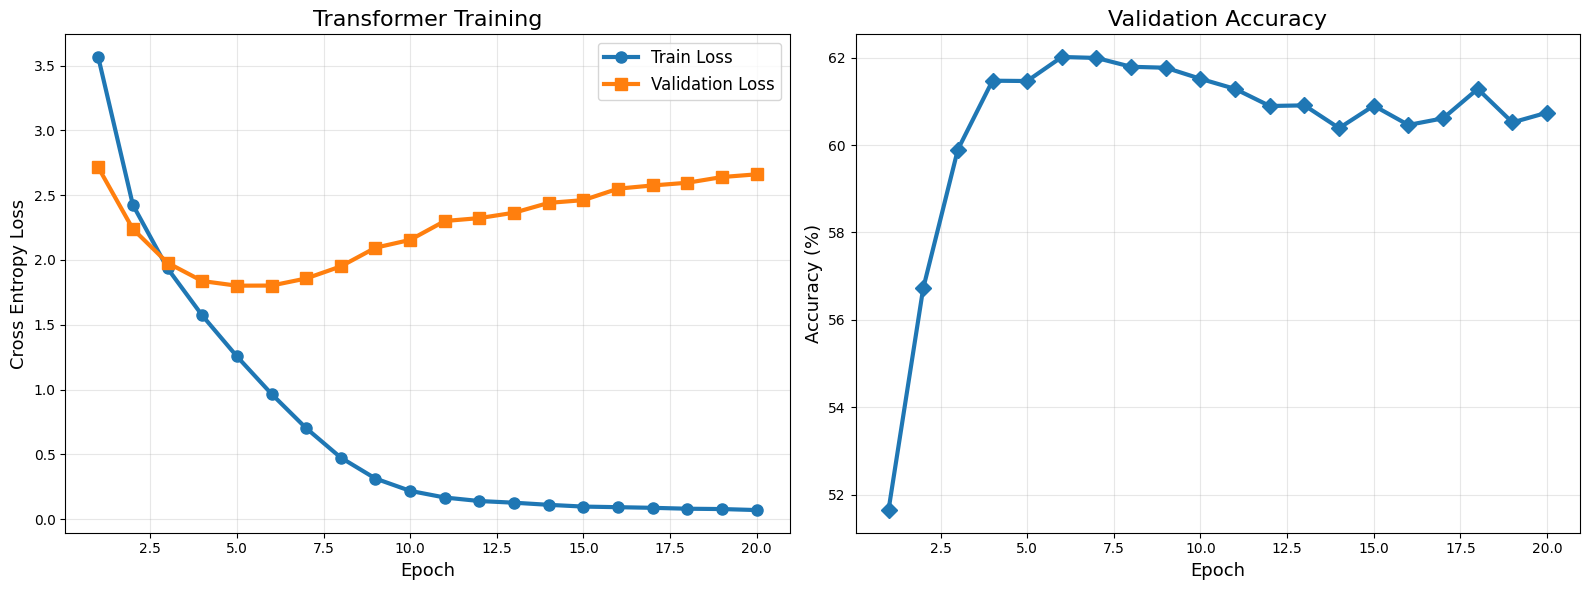

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch

if torch.cuda.is_available():
    print(f"GPU is active: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU (or TPU)")

model = Transformer(
    src_vocab_size = len(src_vocab),
    tgt_vocab_size = len(tgt_vocab),
    d_model = 512,
    n_heads = 8,
    num_layers = 6
).to(device)


PAD_IDX = tgt_vocab["<PAD>"]

criterion = nn.CrossEntropyLoss(
    ignore_index = PAD_IDX
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-4
)

num_epochs = 20

train_losses = []
val_losses = []
accuracy = []

for epoch in range(num_epochs):

  model.train()
  train_loss = 0
  for batch in train_loader:
    src = batch["src"].to(device)
    tgt = batch["tgt"].to(device)
    tgt_input = tgt[:,:-1]
    tgt_output = tgt[:,1:]
    src_mask = make_src_mask(
        src,
        PAD_IDX
    )
    tgt_mask = make_tgt_mask(
        tgt_input,
        PAD_IDX
    )

    output = model(
        src,
        tgt_input,
        src_mask,
        tgt_mask
    )

    output = output.reshape(-1,output.shape[-1])
    tgt_output = tgt_output.reshape(-1)

    optimizer.zero_grad()

    loss = criterion(output,tgt_output)

    loss.backward()

    optimizer.step()
    train_loss += loss.item()


  model.eval()
  val_loss = 0
  correct = 0
  total = 0
  with torch.no_grad():
    for batch in val_loader:

      src = batch["src"].to(device)
      tgt = batch["tgt"].to(device)
      tgt_input = tgt[:,:-1]
      tgt_output = tgt[:,1:]

      src_mask = make_src_mask(src,PAD_IDX)
      tgt_mask = make_tgt_mask(tgt_input,PAD_IDX)
      output = model(
          src,tgt_input,src_mask,tgt_mask
      )
      output = output.reshape(-1,output.shape[-1])
      prediction = output.argmax(dim=-1)
      tgt_output = tgt_output.reshape(-1)

      mask = (tgt_output != PAD_IDX)

      correct += ((tgt_output == prediction) & mask).sum().item()
      total += mask.sum().item()


      loss = criterion(output,tgt_output)
      val_loss += loss.item()

    print(epoch,"---------")
    print("validation loss : ",val_loss/len(val_loader))
    val_losses.append(val_loss / len(val_loader))
    print("training loss : ",train_loss/len(train_loader))
    train_losses.append(train_loss / len(train_loader))
    print("accuracy : ",(correct / total) * 100 )
    accuracy.append((correct/total) * 100 )
    print()

import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses,
         linewidth=3,
         marker='o',
         markersize=8,
         label='Train Loss')

plt.plot(epochs, val_losses,
         linewidth=3,
         marker='s',
         markersize=8,
         label='Validation Loss')

plt.title("Transformer Training", fontsize=16)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Cross Entropy Loss", fontsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.subplot(1,2,2)
plt.plot(epochs,
         accuracy,
         linewidth=3,
         marker='D',
         markersize=8)

plt.title("Validation Accuracy", fontsize=16)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
idx_to_tgt = {idx: token for token , idx in tgt_vocab.items()}
idx_to_src = {idx: token for token , idx in src_vocab.items()}

def translate(sentence,model,max_len = 50):
  model.eval()
  with torch.no_grad():
    src = numericalize(sentence,src_vocab,tokenize_en)
    src = torch.tensor(src).unsqueeze(0).to(device)
    src_mask = make_src_mask(src,PAD_IDX)

    encoder_output = model.Encoder(src,src_mask)
    decoder_input = torch.tensor([[tgt_vocab["<BOS>"]]],device = device)


    for _ in range(max_len):

      tgt_mask = make_tgt_mask(decoder_input,PAD_IDX)

      decoder_output = model.Decoder(
          decoder_input,
          encoder_output,
          src_mask,
          tgt_mask
      )

      output = model.fc(decoder_output)
      next_token = output[:,-1].argmax(dim=-1)
      next_token = next_token.unsqueeze(1)

      decoder_input = torch.cat([decoder_input,next_token],dim = 1)

      if(next_token.item() == tgt_vocab["<EOS>"]):
        break


      words = []
      for token_id in decoder_input[0]:
        words.append(idx_to_tgt[token_id.item()])

      sentence = ""
      for w in words:
        if w != "<BOS>" and w != "<EOS>":
          sentence += w + " "

    print("output : ",sentence.strip())





input = "A man is playing football"
print("input : ",input)
translate(input,model)

input :  A man is playing football
output :  ein mann spielt football .
